# Daily Challenge - Statistics for Machine Learning

Customer churn distribution analysis


# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [3]:
## load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = pd.read_csv('Churn_Modelling.csv')

In [4]:
## make into a dataframe called df
df = pd.DataFrame(file_1)

In [5]:
## output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# EDA

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [13]:
# How many customers left the bank? 20.37%

display (df.groupby('Exited')
   .size()
   .reset_index(name='Count')
   .assign(Percentage=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2))
)


,Exited,Count,Percentage
0,0,7963,79.63
1,1,2037,20.37


In [14]:
## Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1),
# respectively

df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

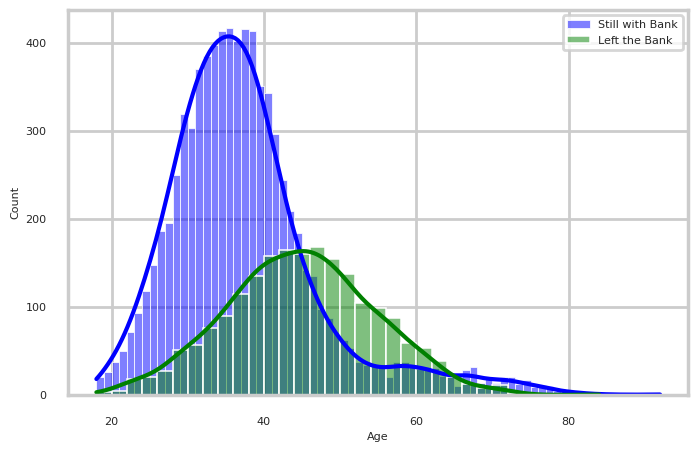

In [15]:
##  Plot the age distribution for customers who stayed with the bank and those who left using seaborn,
## with different colors for each group and a legend.

sns.histplot(df_0['Age'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1['Age'], color='green', label='Left the Bank', kde=True)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [17]:
## Calculate the mean and standard deviation of the age for customers who stayed with the bank.

df_0.Age.mean() , df_0.Age.std()

(np.float64(37.40838879819164), 10.125362911047631)

In [18]:
## Calculate the mean and standard deviation of the age for customers who left the bank.

df_1.Age.mean() , df_1.Age.std()

(np.float64(44.8379970544919), 9.761561555507132)

In [19]:
## Perform a t-test to compare the ages of customers who stayed and left the bank.

print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0.Age, df_1.Age, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0['Age'].mean()
mean_left = df_1['Age'].mean()

print(f"\nMean age (stayed): {mean_stayed:.1f}")
print(f"Mean age (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean age between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean age between the two groups.")

# Customers who left the bank are ~7 years older on average, which suggests age is strongly associated with churn.


H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: -30.4192
P-value: 0.000000

Mean age (stayed): 37.4
Mean age (left): 44.8
difference: -7.4

Conclusion: Reject H0 (p = 0.000000 < 0.05)
There is a statistically significant difference in mean age between customers who stayed and those who left.


### Using Bootstrapping

In [54]:
# Take original data
# Resample with replacement
# Calculate a statistic of interest (mean, standard deviation, etc.)
# Repeat thousands of times

## Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)  # creates an “empty container” to store results
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)  # takes a random sample, with replacement, of the same size as the original data
        bs_s[i] = func(bs_abc)  # applies a function (e.g., std, mean)
    return bs_s   # returns simulated results


In [25]:
## Calculate the difference in means and shift the ages to the overall mean.

# Difference in observed mean ages between those who left and those who didn't
obs_diff = df_1['Age'].mean() - df_0['Age'].mean()
print(obs_diff.round(2))

# Overall mean age
overall_mean = df['Age'].mean()
print(overall_mean.round(2))

# ✔ “remove the original differences between the groups” and leave them all with the SAME mean
# ✔ Objective: to simulate “there is no real difference between groups”
df_0_shifted = df_0['Age'] - df_0['Age'].mean() + overall_mean
df_1_shifted = df_1['Age'] - df_1['Age'].mean() + overall_mean
display (df_0_shifted.head())
display(df_1_shifted.head())

7.43
38.92


,Age
1,42.513411
3,40.513411
4,44.513411
6,51.513411
8,45.513411


,Age
0,36.083803
2,36.083803
5,38.083803
7,23.083803
16,52.083803


In [26]:
## Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

# Bootstrap parameters
n_iterations = 1000
boot_std_0, boot_std_1 = [], []

# Bootstrap sampling
for _ in range(n_iterations):
    sample_0 = df_0['Age'].sample(frac=1, replace=True)
    sample_1 = df_1['Age'].sample(frac=1, replace=True)
    boot_std_0.append(sample_0.std())
    boot_std_1.append(sample_1.std())

# Results
boot_std_0 = np.array(boot_std_0)
boot_std_1 = np.array(boot_std_1)
diff = boot_std_0 - boot_std_1

print(f"Std (Stayed):     {boot_std_0.mean():.4f} ± {boot_std_0.std():.4f}")        #original data: 10.1254
print(f"Std (Left):       {boot_std_1.mean():.4f} ± {boot_std_1.std():.4f}")        #original data: 9.7616
print(f"Difference (0-1): {diff.mean():.4f} ± {diff.std():.4f}")


Std (Stayed):     10.1301 ± 0.1234
Std (Left):       9.7616 ± 0.1441
Difference (0-1): 0.3685 ± 0.1947


In [33]:
## Calculate the p-value by comparing the difference in means to the bootstrap distribution.

# mean difference bootstrap
def bootstrap_mean_diff(a, b, size=1000):
  diffs = np.zeros(size)
  for i in range(size):
     a_sample = np.random.choice(a, size=len(a), replace=True)
     b_sample = np.random.choice(b, size=len(b), replace=True)
     diffs[i] = np.mean(b_sample) - np.mean(a_sample)
  return diffs

bs_diffs = bootstrap_mean_diff(df_0_shifted, df_1_shifted)

 ## Calculate the p-value by comparing the difference in means to the bootstrap distribution.
 # p-value (two-tailed)

# 👉 “How many times does chance produce a difference equal to or greater than the real one?”
p_value = np.mean(np.abs(bs_diffs) >= np.abs(obs_diff))
print(f"Observed difference: {obs_diff:.4f}")
print(f"P-value: {p_value:.6f}")

Observed difference: 7.4296
P-value: 0.000000


In [34]:
alpha = 0.05

if p_value < alpha:
    print("\nConclusion: Reject H0")
    print("There is a statistically significant difference in ages between the two groups.")
else:
    print("\nConclusion: Fail to reject H0")
    print("There is no statistically significant difference in ages between the two groups.")

# Bootstrap results confirm the t-test findings, increasing confidence in the results.


Conclusion: Reject H0
There is a statistically significant difference in ages between the two groups.


### Conclusion
Do we reject the Null Hypothesis ? Why ?

*We reject the null hypothesis because the p-value is less than 0.05 (α). The observed difference in mean ages between the two groups  (~7 years) is unlikely due to chance alone, indicating a statistically significant difference.*

## Hypothesis 2: Credit Score

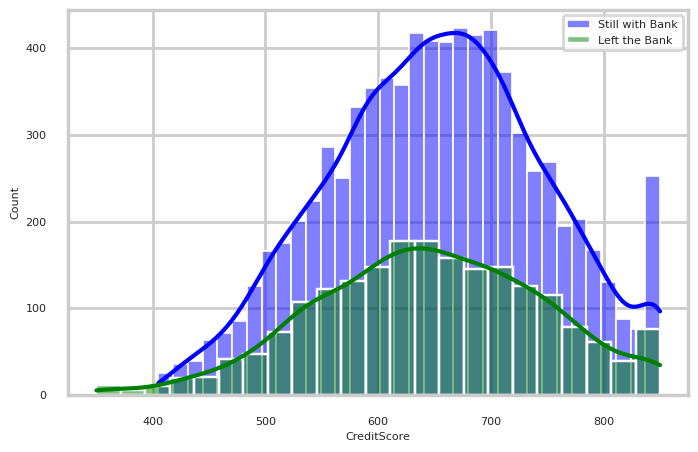

In [35]:
## Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).

sns.histplot(df_0['CreditScore'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1['CreditScore'], color='green', label='Left the Bank', kde=True)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [36]:
## Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0.CreditScore, df_1.CreditScore, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0['CreditScore'].mean()
mean_left = df_1['CreditScore'].mean()

print(f"\nMean CreditScore (stayed): {mean_stayed:.1f}")
print(f"Mean CreditScore (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean CreditScore between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean CreditScore between the two groups.")

# Customers who left the bank have ~6.5 credit score lower, which suggests CreditScore is statistically significant but with small effect size


H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: 2.6347
P-value: 0.008465

Mean CreditScore (stayed): 651.9
Mean CreditScore (left): 645.4
difference: 6.5

Conclusion: Reject H0 (p = 0.008465 < 0.05)
There is a statistically significant difference in mean CreditScore between customers who stayed and those who left.


### Conclusion
Do we reject the Null Hypothesis ? Why ?

*We reject the null hypothesis (p < 0.05). The difference in mean CreditScore between customers who stayed and those who left is statistically significant and unlikely due to chance. Notably, customers who stayed show a higher mean CreditScore, suggesting a potential relationship between CreditScore and churn behavior.*

## Hypothesis 3: Balance

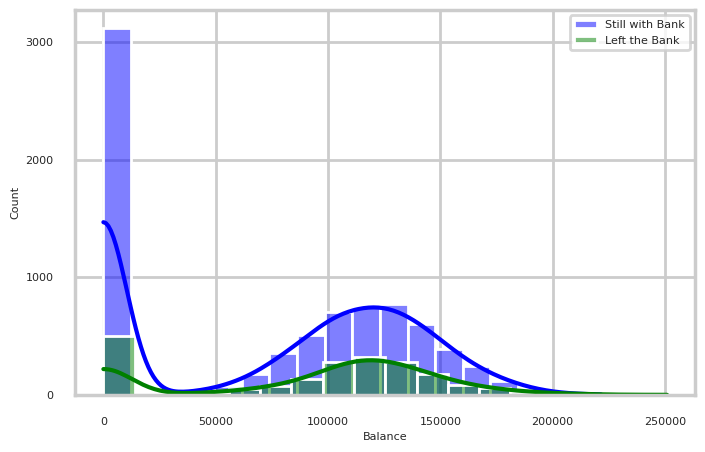

In [37]:
## Plot the distribution of Balance for both groups (Still with bank and Left the bank).
sns.histplot(df_0['Balance'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1['Balance'], color='green', label='Left the Bank', kde=True)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [40]:
##  Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.

print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0.Balance, df_1.Balance, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0['Balance'].mean()
mean_left = df_1['Balance'].mean()

print(f"\nMean Balance (stayed): {mean_stayed:.1f}")
print(f"Mean Balance (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean Balance between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean Balance between the two groups.")

# Customers who left the bank have ~ $ 18.363 less in average, which suggests Balance is strongly associated with churn.


H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: -12.4713
P-value: 0.000000

Mean Balance (stayed): 72745.3
Mean Balance (left): 91108.5
difference: -18363.2

Conclusion: Reject H0 (p = 0.000000 < 0.05)
There is a statistically significant difference in mean Balance between customers who stayed and those who left.


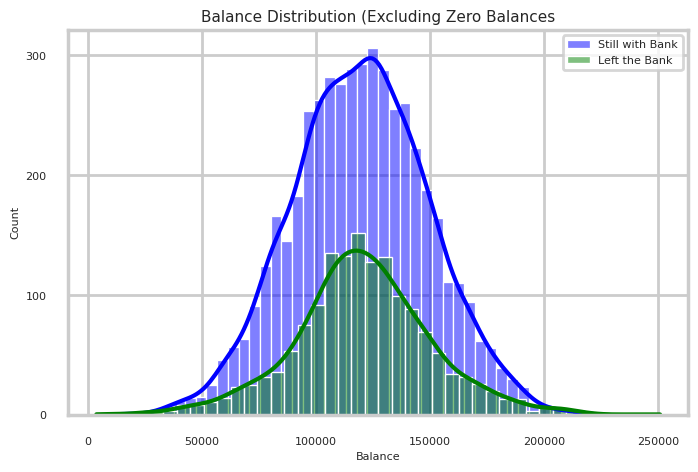

In [46]:
## Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.

# Filter balances different to 0
df_0_nonzero = df_0[df_0['Balance'] != 0]
df_1_nonzero = df_1[df_1['Balance'] != 0]

sns.histplot(df_0_nonzero['Balance'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1_nonzero['Balance'], color='green', label='Left the Bank', kde=True)
plt.title('Balance Distribution (Excluding Zero Balances)', fontsize=11)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()


In [47]:
## Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

# Balance != 0
print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0_nonzero.Balance, df_1_nonzero.Balance, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0_nonzero['Balance'].mean()
mean_left = df_1_nonzero['Balance'].mean()

print(f"\nMean Balance != 0 (stayed): {mean_stayed:.1f}")
print(f"Mean Balance != 0 (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean Balance (!= 0) between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean Balance (!= 0) between the two groups.")

# The apparent effect of Balance is driven by zero-balance accounts, suggesting inactivity rather than financial level explains churn.

H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: -1.3605
P-value: 0.173800

Mean Balance != 0 (stayed): 119535.9
Mean Balance != 0 (left): 120747.0
difference: -1211.1

Conclusion: Fail to reject H0 (p = 0.173800 ≥ 0.05)
There is no statistically significant difference in mean Balance (!= 0) between the two groups.


## Conclusion

Do we reject the Null Hypothesis ? Why ?

*We fail to reject the null hypothesis (p ≥ 0.05). When excluding zero balances to focus on active accounts, the difference in mean balance between customers who stayed and those who left is not statistically significant, suggesting the observed difference could be attributed to random variation. Therefore, there is no strong statistical evidence linking balance to churn behavior.*

## Hypothesis 4: Estimated Salary

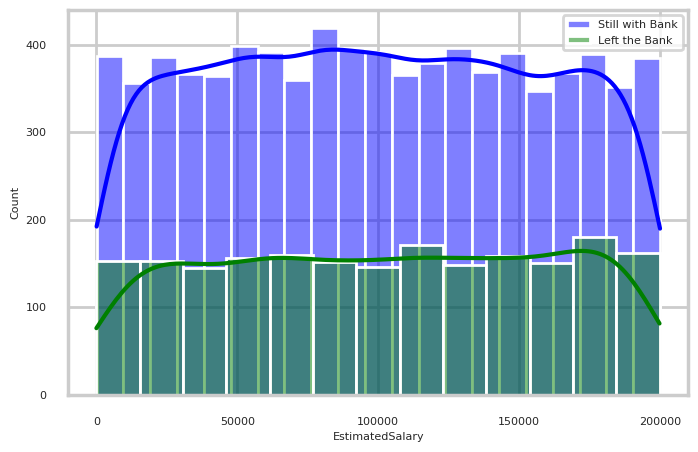

In [48]:
## Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1['EstimatedSalary'], color='green', label='Left the Bank', kde=True)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [50]:
## Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.

print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0.EstimatedSalary, df_1.EstimatedSalary, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0['EstimatedSalary'].mean()
mean_left = df_1['EstimatedSalary'].mean()

print(f"\nMean EstimatedSalary (stayed): {mean_stayed:.1f}")
print(f"Mean EstimatedSalary (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean EstimatedSalary between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean EstimatedSalary between the two groups." )

H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: -1.2034
P-value: 0.228925

Mean EstimatedSalary (stayed): 99738.4
Mean EstimatedSalary (left): 101465.7
difference: -1727.3

Conclusion: Fail to reject H0 (p = 0.228925 ≥ 0.05)
There is no statistically significant difference in mean EstimatedSalar between the two groups.


### Using Bootstrapping

In [52]:
## Calculate the difference in means and shift the EstimatedSalary for both groups.
diff_means = np.mean(df_1.EstimatedSalary) - np.mean(df_0.EstimatedSalary)
mean_salary = np.mean(df.EstimatedSalary)

display (diff_means.round(2), mean_salary.round(2) )


salary_shifted_0 = df_0.EstimatedSalary + mean_salary - np.mean(df_0.EstimatedSalary)
salary_shifted_1 = df_1.EstimatedSalary + mean_salary - np.mean(df_1.EstimatedSalary)

np.float64(1727.29)

np.float64(100090.24)

In [55]:
## Calculate the bootstrap sample means for both groups and their difference.
bs_n_0 = bs_choice(salary_shifted_0, np.mean, 10000)
bs_n_1 = bs_choice(salary_shifted_1, np.mean, 10000)
bs_mean = bs_n_1 - bs_n_0

In [57]:
## Calculate the p-value based on the bootstrap distribution of the difference in means.

p = np.sum(np.abs(bs_mean) >= np.abs(diff_means)) / len(bs_mean)
p

# consistent across parametric (t-test) and non-parametric (bootstrap) approaches

np.float64(0.2334)

### Conclusion
Do we reject the Null Hypothesis ? Why ?

*We fail to reject the null hypothesis. Both the t-test (p = 0.2289) and bootstrap (p = 0.2334) yield p-values greater than α = 0.05, indicating that the difference in mean EstimatedSalary between customers who stayed and those who left is not statistically significant and could be due to random chance.*

## Final Conclusion
What will be the most helpful feature in predicting churning?

*Based on the analysis, **Age is the strongest predictor of churn, with customers who leave being significantly older**.*
*CreditScore also shows a statistically significant, although with a smaller effect size.*

*Balance appears significant only due to zero-balance accounts, and loses importance when considering active customers. EstimatedSalary does not show a meaningful relationship with churn*.

*Banks should focus retention strategies on **older and potentially inactive customers**.*